# Pneumonia-CNN Model Using Grayscale
--------------------

## Objectives of the Pneumonia Detection Model

The primary objectives of this project are:

1. **Early Detection of Pneumonia**:
    - Develop a robust Convolutional Neural Network (CNN) model to classify chest X-ray images into two categories: NORMAL and PNEUMONIA.
    - Enable early diagnosis to assist healthcare professionals in providing timely treatment.

2. **Data Augmentation**:
    - Enhance the dataset by applying transformations such as flipping, rotation, zooming, and brightness adjustments to improve the model's generalization capabilities.

3. **Model Optimization**:
    - Use techniques like dropout layers and early stopping to prevent overfitting and improve the model's performance on unseen data.

4. **Evaluation and Visualization**:
    - Evaluate the model's performance on a separate test dataset and visualize predictions to understand its strengths and weaknesses.

5. **Future Improvements**:
    - Plan to incorporate transfer learning using pre-trained models like MobileNetV2 to achieve higher accuracy and efficiency.

# Importing data

In [1]:
import kagglehub
import os
import numpy
import keras
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import layers

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

print(path)

train_dir = os.path.join(path, 'chest_xray', 'train')
test_dir = os.path.join(path, 'chest_xray', 'test')
val_dir = os.path.join(path, 'chest_xray', 'val')

print('Train dir:',train_dir)


/opt/anaconda3/envs/keras/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/jafarjafarov/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
/Users/jafarjafarov/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
Train dir: /Users/jafarjafarov/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train


### Dataset Preparation

The datasets for training, validation, and testing were prepared using TensorFlow's `image_dataset_from_directory` function. The key steps and configurations are as follows:

1. **Image Dimensions**:
    - All images were resized to a uniform size of `180x180` pixels using the `image_size` parameter. This ensures consistency in input dimensions for the model.

2. **Batch Size**:
    - A batch size of `32` was used for efficient training and evaluation.

3. **Grayscale Images**:
    - The `color_mode` was set to `'grayscale'` to load the chest X-ray images as single-channel grayscale images, reducing computational complexity.

4. **Binary Labels**:
    - The `label_mode` was set to `'binary'` since this is a binary classification problem (NORMAL vs. PNEUMONIA).

5. **Random Seed**:
    - A seed value of `123` was used to ensure reproducibility in dataset shuffling and splitting.

6. **Directories**:
    - The datasets were loaded from the following directories:
        - `train_dir`: Contains the training data.
        - `val_dir`: Contains the validation data.
        - `test_dir`: Contains the test data.

These datasets were later optimized using caching, shuffling, and prefetching to improve training efficiency and reduce latency during data loading.

In [2]:
img_width, img_height = 180, 180
batch_size = 32

train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=(img_width, img_height),
    batch_size=batch_size,
    label_mode='binary',
    color_mode='grayscale',  # Load images as grayscale
    seed=123
)

val_dataset = image_dataset_from_directory(
    val_dir,
    image_size=(img_width, img_height),
    batch_size=batch_size,
    label_mode='binary',
    color_mode='grayscale',  # Load images as grayscale
    seed=123
)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(img_width, img_height),
    batch_size=batch_size,
    label_mode='binary',
    color_mode='grayscale',  # Load images as grayscale
    seed=123
)


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


### Data Augmentation and Dataset Optimization

1. **Data Augmentation**:
    - A `Sequential` model was created for data augmentation using the following transformations:
        - `RandomFlip("horizontal")`: Randomly flips images horizontally.
        - `RandomRotation(0.1)`: Applies random rotations to images within a range of ±10%.
        - `RandomTranslation(0.1, 0.1)`: Translates images randomly by up to 10% of their width and height.
        - `RandomZoom(0.1)`: Zooms into images randomly by up to 10%.
        - `RandomBrightness(0.1)`: Adjusts the brightness of images randomly by up to 10%.
        - `RandomContrast(0.1)`: Adjusts the contrast of images randomly by up to 10%.

2. **Dataset Optimization**:
    - The datasets were optimized for efficient training and evaluation:
        - **Caching**: The datasets were cached to avoid redundant computations during training.
        - **Shuffling**: The training dataset was shuffled with a buffer size of 1000 to ensure randomness.
        - **Prefetching**: The datasets were prefetched with a buffer size of `AUTOTUNE` to overlap data preprocessing and model execution, improving training efficiency.

In [3]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
        layers.RandomCrop(200, 200),  # Added random cropping
        layers.Resizing(img_width, img_height)  # Resize back to target dimensions
    ]
)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Data Augmentation

2025-05-08 19:38:18.642319: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


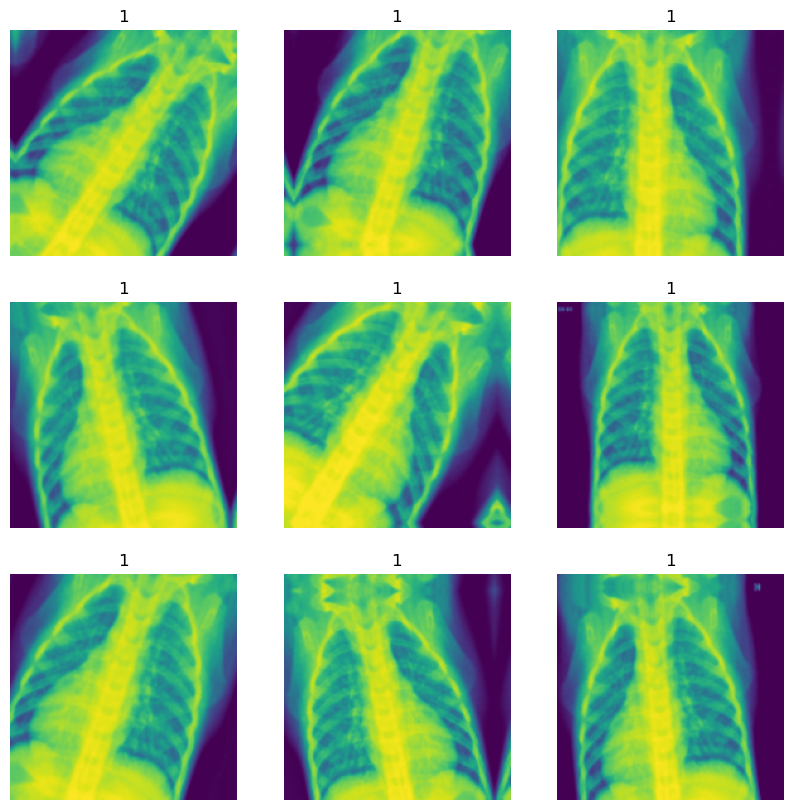

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.title(int(labels[0]))
        plt.axis("off")

### Model Architecture

The model is a Convolutional Neural Network (CNN) designed for binary classification of grayscale chest X-ray images (NORMAL vs. PNEUMONIA). Below is a detailed breakdown of the architecture:

1. **Input Layer**:
    - The input layer is defined with a shape of `(img_width, img_height, 1)` to accommodate grayscale images resized to `180x180` pixels.

2. **Data Augmentation**:
    - The input images are passed through a data augmentation pipeline (`data_augmentation`) to improve generalization by applying transformations such as flipping, rotation, zooming, and brightness adjustments.

3. **Rescaling**:
    - The pixel values are normalized to the range `[0, 1]` using `layers.Rescaling(1./255)`.

4. **Convolutional and Pooling Layers**:
    - **Conv2D (32 filters)**: Extracts low-level features using a 3x3 kernel with ReLU activation.
    - **MaxPooling2D**: Reduces spatial dimensions by applying a 2x2 pooling operation.
    - **Dropout (0.3)**: Prevents overfitting by randomly dropping 30% of the neurons.

    - **Conv2D (64 filters)**: Extracts more complex features with a 3x3 kernel and ReLU activation.
    - **MaxPooling2D**: Further reduces spatial dimensions.
    - **Dropout (0.3)**: Another dropout layer to enhance regularization.

    - **Conv2D (128 filters)**: Captures higher-level features with a 3x3 kernel and ReLU activation.
    - **MaxPooling2D**: Reduces spatial dimensions further.
    - **Dropout (0.4)**: Increased dropout rate to 40% for better regularization.

    - **Conv2D (256 filters)**: Extracts the most complex features with a 3x3 kernel and ReLU activation.
    - **MaxPooling2D**: Final pooling layer to reduce dimensions.

5. **Flatten Layer**:
    - Converts the 2D feature maps into a 1D vector for the fully connected layer.

6. **Dropout (0.5)**:
    - A final dropout layer with a 50% rate to prevent overfitting.

7. **Output Layer**:
    - A dense layer with a single neuron and a sigmoid activation function to output a probability for binary classification.

8. **Model Summary**:
    - The model is built using the Keras Functional API, and the architecture is summarized using `model.summary()`.

This architecture is designed to effectively extract hierarchical features from chest X-ray images while incorporating regularization techniques to prevent overfitting.

In [5]:
inputs = layers.Input(shape=(img_width, img_height, 1))  # Changed to 1 channel for grayscale
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(32, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)  # Added Dropout after pooling
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.3)(x)  # Added Dropout after pooling
x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.4)(x)  # Increased Dropout rate
x = layers.Conv2D(256, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)  # Existing Dropout
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        20,737 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408,577 (1.56 MB)

 Trainable params: 408,577 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation and Training

1. **Model Compilation**:
    - The model was compiled using the following configurations:
        - **Loss Function**: `binary_crossentropy` was used as the loss function since this is a binary classification problem (NORMAL vs. PNEUMONIA).
        - **Optimizer**: `adam` optimizer was chosen for its adaptive learning rate and efficiency in training deep learning models.
        - **Metrics**: `accuracy` was used as the evaluation metric to monitor the model's performance during training and validation.

2. **Callbacks**:
    - Two callbacks were implemented to enhance the training process:
        - **ModelCheckpoint**:
            - Saves the model with the best validation loss during training.
            - The model is saved to the file `convnet_from_scratch_with_augmentation.keras`.
        - **EarlyStopping**:
            - Monitors the validation loss (`val_loss`) and stops training if it does not improve for 3 consecutive epochs (patience=3).
            - Restores the best weights to ensure the model achieves optimal performance.

3. **Model Training**:
    - The model was trained using the `fit` method with the following parameters:
        - **Training Dataset**: `train_dataset` was used for training the model.
        - **Validation Dataset**: `val_dataset` was used to evaluate the model's performance after each epoch.
        - **Epochs**: The model was trained for up to 40 epochs.
        - **Callbacks**: The `ModelCheckpoint` and `EarlyStopping` callbacks were applied to save the best model and prevent overfitting.

    - The training history, including metrics such as accuracy and loss for both training and validation datasets, was stored in the `history` object for further analysis and visualization.

In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,  # Reduced patience for quicker stopping
        verbose=1,
        restore_best_weights=True  # Restore the best weights
    )
]
history = model.fit(train_dataset, epochs=40, validation_data=val_dataset, callbacks=callbacks)

Epoch 1/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 143ms/step - accuracy: 0.7228 - loss: 0.5888 - val_accuracy: 0.5000 - val_loss: 0.6816
Epoch 2/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.7807 - loss: 0.4592 - val_accuracy: 0.6875 - val_loss: 0.7579
Epoch 3/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.8481 - loss: 0.3598 - val_accuracy: 0.6250 - val_loss: 0.9677
Epoch 4/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 146ms/step - accuracy: 0.8648 - loss: 0.3266 - val_accuracy: 0.6875 - val_loss: 0.5431
Epoch 5/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 141ms/step - accuracy: 0.9011 - loss: 0.2677 - val_accuracy: 0.5000 - val_loss: 0.7750
Epoch 6/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 141ms/step - accuracy: 0.8989 - loss: 0.2551 - val_accuracy: 0.6875 - val_loss: 0.5474
Epoch 7/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.9155 - loss: 0.2220 - val_accuracy: 0.6875 - val_loss: 0.6267
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


### Plotting Training and Validation Metrics

In this section, we visualize the training and validation accuracy and loss over the epochs. This helps us understand how well the model is learning and whether it is overfitting or underfitting.

- **Accuracy Plot**: Shows the training and validation accuracy for each epoch.
- **Loss Plot**: Displays the training and validation loss for each epoch.

These plots provide insights into the model's performance and guide further tuning or adjustments.

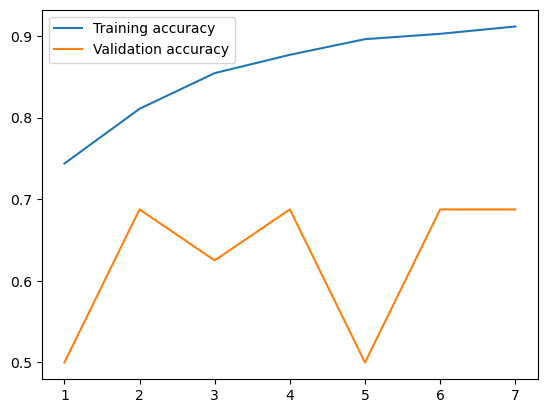

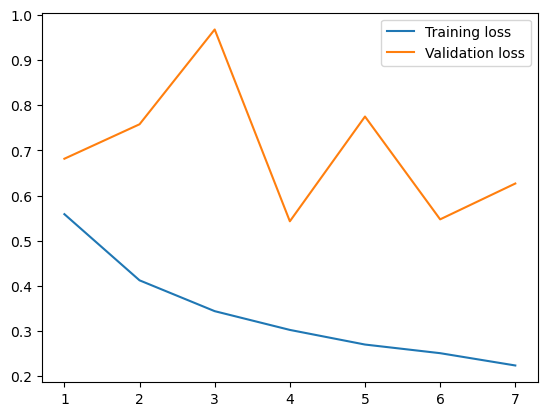

In [7]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = list(range(1, len(accuracy)+1))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.show()

### Evaluating the Trained Model on the Test Dataset

In this step, we are loading the trained model (`convnet_from_scratch_with_augmentation.keras`) and evaluating its performance on the test dataset. The `evaluate` method is used to calculate the test loss and accuracy, which are printed to assess the model's generalization capability on unseen data.

In [8]:
test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8391 - loss: 0.3880
Test accuracy: 0.8413461446762085


### Visualizing Model Predictions on Test Data

This section demonstrates the process of evaluating the trained model on the test dataset and visualizing its predictions. The key steps are as follows:

1. **Model Loading**:
    - The trained model is loaded from the file `convnet_from_scratch_with_augmentation.keras` using `keras.models.load_model`.

2. **Evaluation**:
    - The model's performance is evaluated on the test dataset using the `evaluate` method, which computes the test loss and accuracy. These metrics are printed to assess the model's generalization capability.

3. **Original Dataset Creation**:
    - The original test dataset is created using `image_dataset_from_directory` without any transformations. This ensures that the class names (`NORMAL` and `PNEUMONIA`) can be extracted for labeling.

4. **Predictions**:
    - Predictions are generated for a batch of images from the test dataset using the `predict` method. The predicted probabilities are converted to binary classes (`0` for NORMAL and `1` for PNEUMONIA) using a threshold of 0.5.

5. **Visualization**:
    - A grid of images is displayed using `matplotlib.pyplot`. For each image:
        - The true label and predicted label are shown in the title.
        - The title color is set to green if the prediction is correct and red if it is incorrect.
        - Grayscale images are displayed using the `cmap="gray"` parameter.

6. **Insights**:
    - This visualization provides a clear understanding of the model's predictions and highlights any misclassifications, aiding in further analysis and debugging.

The visualization helps in assessing the model's strengths and weaknesses by comparing the true labels with the predicted labels for individual samples.

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8391 - loss: 0.3880
Test Loss: 0.385
Test Accuracy: 0.841
Found 624 files belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


2025-05-08 19:44:31.351416: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


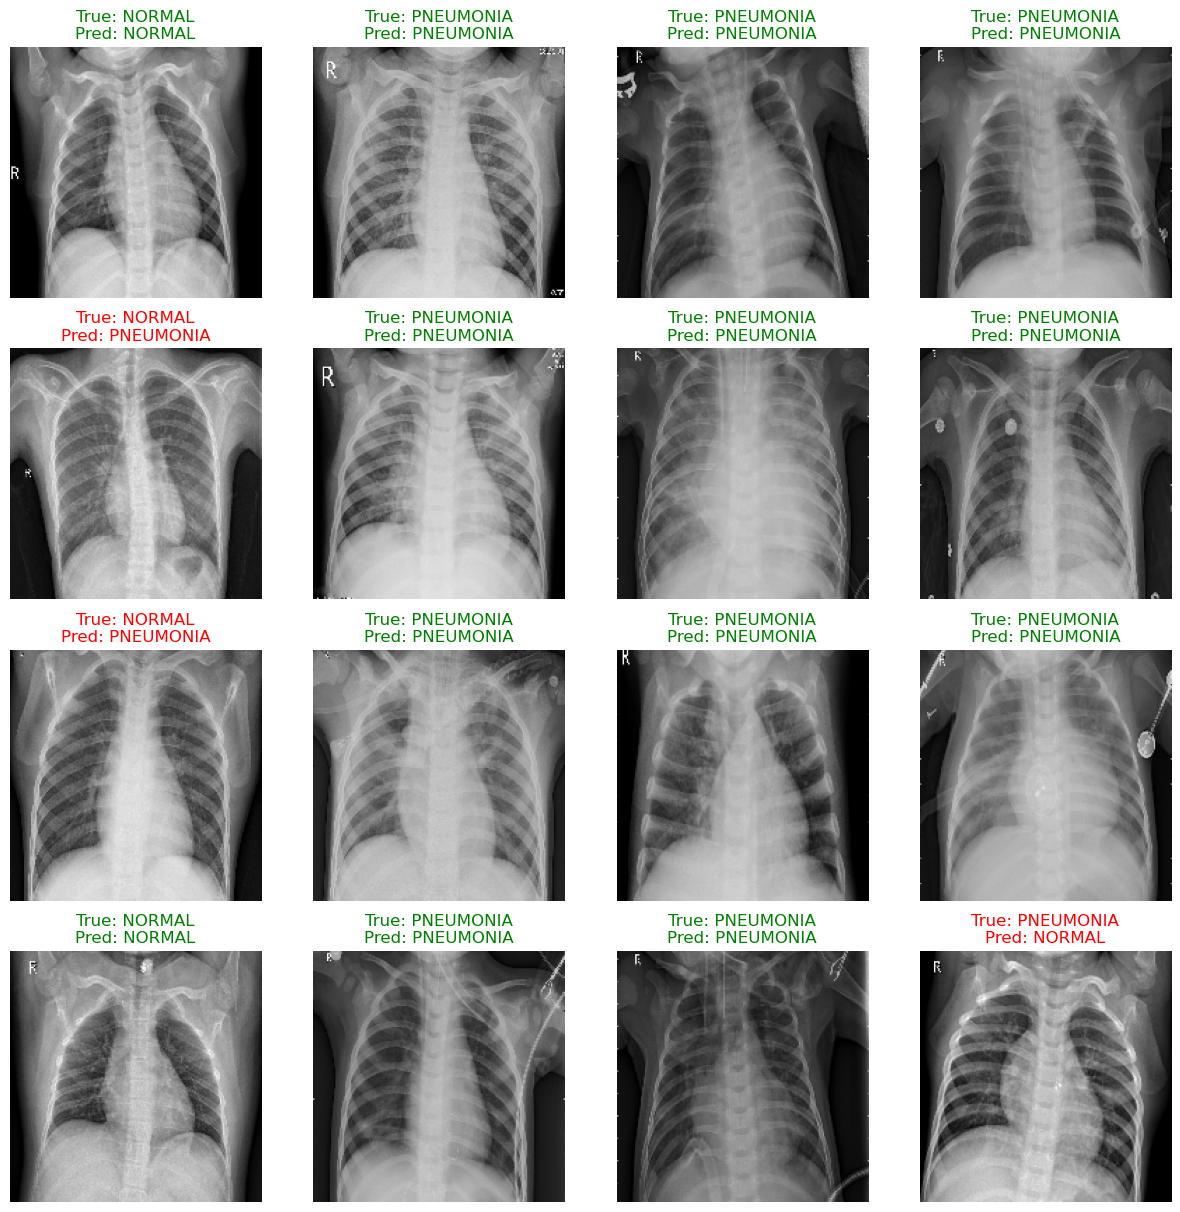

In [10]:
import matplotlib.pyplot as plt
import numpy as np


test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")

test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

# Create the original dataset without transformations
original_test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(img_width, img_height),
    batch_size=batch_size,
    label_mode='binary',
    color_mode='grayscale',  # Load images as grayscale
    seed=123
)

# Extract class names from the original dataset
class_names = original_test_dataset.class_names

# Use the transformed test_dataset for evaluation and predictions
plt.figure(figsize=(15, 15))
max_images = 16
for images, labels in test_dataset.take(1): 
    predictions = test_model.predict(images)
    predicted_classes = (predictions > 0.5).astype("int32").flatten()  # Convert probabilities to binary classes
    labels = labels.numpy()  # Convert labels to a NumPy array
    for i in range(min(len(images), max_images)):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")  # Display grayscale images
        true_label = "PNEUMONIA" if labels[i] == 1 else "NORMAL"
        predicted_label = "PNEUMONIA" if predicted_classes[i] == 1 else "NORMAL"
        color = "green" if predicted_label == true_label else "red"
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
        plt.axis("off")
plt.show()

## Final Thoughts and Conclusion

The Pneumonia-CNN project demonstrates the potential of deep learning in medical imaging, specifically for the early detection of pneumonia using chest X-ray images. By leveraging a Convolutional Neural Network (CNN) architecture, data augmentation, and optimization techniques, the model achieved a commendable performance on the test dataset, with a test accuracy of approximately 84.1%. This highlights the effectiveness of the approach in distinguishing between NORMAL and PNEUMONIA cases.

### Key Achievements:
1. **Model Performance**: The model successfully generalized to unseen data, as evidenced by its test accuracy and loss metrics.
2. **Data Augmentation**: The use of data augmentation techniques improved the model's robustness and ability to handle variations in the dataset.
3. **Regularization**: Techniques like dropout layers and early stopping helped mitigate overfitting, ensuring better performance on the validation and test datasets.
4. **Visualization**: The visualization of predictions provided valuable insights into the model's strengths and areas for improvement.

### Areas for Improvement:
1. **Dataset Size**: The dataset could be expanded to include more diverse and balanced samples, reducing potential biases and improving generalization.
2. **Transfer Learning**: Incorporating pre-trained models like MobileNetV2 or ResNet could enhance accuracy and reduce training time by leveraging features learned from larger datasets.
3. **Hyperparameter Tuning**: A more systematic approach to hyperparameter tuning, such as grid search or Bayesian optimization, could further improve the model's performance.
4. **Class Imbalance**: Addressing any class imbalance in the dataset through techniques like oversampling or weighted loss functions could improve the model's ability to handle minority classes.
5. **Explainability**: Implementing explainability techniques, such as Grad-CAM, could provide insights into the regions of the X-ray images that the model focuses on, aiding in trust and interpretability.
6. **Cross-Validation**: Using cross-validation instead of a single train-validation split could provide a more robust evaluation of the model's performance.

### Conclusion:
This project serves as a solid foundation for leveraging deep learning in medical diagnostics. While the results are promising, there is room for improvement to make the model more robust, accurate, and interpretable. Future work could focus on addressing the identified areas for improvement, ultimately contributing to the development of reliable AI tools for healthcare applications.